In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
carbon = pd.read_excel("carboncredit.xlsx", sheet_name="ECF00-NDEX", header=15)
gas = pd.read_excel("carboncredit.xlsx", sheet_name="TTFC00-USA", header=15)
coal = pd.read_excel("carboncredit.xlsx", sheet_name="ATWQ-FDS", header=15)

carbon.head()

,Date,Last,Settlement Price,Change,% Change,Bid,Ask,Open Interest,CVol
0,2026-07-13,80.21,79.20,NaN,NaN,80.19,80.23,320434,8888.0
1,2026-07-10,79.42,79.20,0.16,0.202429,79.38,79.42,320434,11521.0
2,2026-07-09,78.85,79.04,NaN,NaN,78.85,78.88,320380,14300.0
3,2026-07-08,79.13,79.04,-1.15,-1.434094,79.12,79.13,321609,24875.0
4,2026-07-07,80.34,80.19,-1.60,-1.956229,80.32,80.36,321823,17154.0


In [3]:
carbon = carbon[["Date", "Settlement Price"]].rename(columns={"Settlement Price": "Carbon"})
gas = gas[["Date", "Settlement Price"]].rename(columns={"Settlement Price": "Gas"})
coal = coal[["Date", "Price"]].rename(columns={"Price": "Coal"})

carbon.head()

,Date,Carbon
0,2026-07-13,79.20
1,2026-07-10,79.20
2,2026-07-09,79.04
3,2026-07-08,79.04
4,2026-07-07,80.19


In [4]:
data = carbon.merge(gas, on="Date").merge(coal, on="Date")

data.head()

,Date,Carbon,Gas,Coal
0,2026-07-13,79.20,48.655,114.92
1,2026-07-10,79.20,48.655,114.92
2,2026-07-09,79.04,50.102,118.38
3,2026-07-08,79.04,49.022,118.45
4,2026-07-07,80.19,46.576,115.78


In [5]:
data = data.sort_values("Date").reset_index(drop=True)

data.head()

,Date,Carbon,Gas,Coal
0,2021-07-13,52.79,35.463,129.47
1,2021-07-14,53.30,34.775,129.70
2,2021-07-15,52.91,33.797,129.63
3,2021-07-16,52.82,34.842,130.48
4,2021-07-19,52.34,35.649,131.60


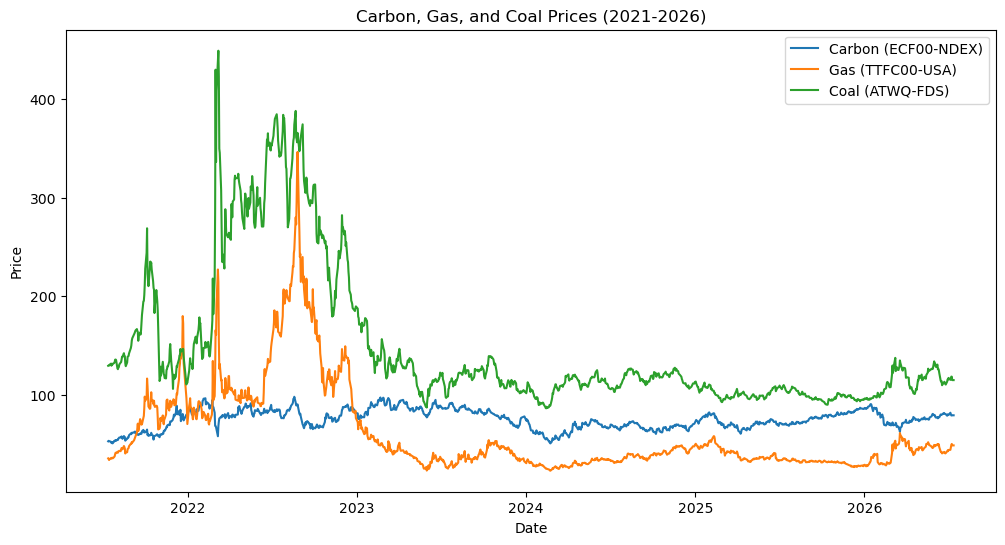

In [6]:
plt.figure(figsize=(12,6))
plt.plot(data["Date"], data["Carbon"], label="Carbon (ECF00-NDEX)")
plt.plot(data["Date"], data["Gas"], label="Gas (TTFC00-USA)")
plt.plot(data["Date"], data["Coal"], label="Coal (ATWQ-FDS)")
plt.legend()
plt.title("Carbon, Gas, and Coal Prices (2021-2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [7]:
data["Carbon Return (%)"] = data["Carbon"].pct_change() * 100
data["Gas Return (%)"] = data["Gas"].pct_change() * 100
data["Coal Return (%)"] = data["Coal"].pct_change() * 100

data.head()

,Date,Carbon,Gas,Coal,Carbon Return (%),Gas Return (%),Coal Return (%)
0,2021-07-13,52.79,35.463,129.47,NaN,NaN,NaN
1,2021-07-14,53.30,34.775,129.70,0.966092,-1.940050,0.177647
2,2021-07-15,52.91,33.797,129.63,-0.731707,-2.812365,-0.053971
3,2021-07-16,52.82,34.842,130.48,-0.170100,3.091990,0.655712
4,2021-07-19,52.34,35.649,131.60,-0.908747,2.316170,0.858369


In [8]:
data = data.dropna().reset_index(drop=True)

data.head()

,Date,Carbon,Gas,Coal,Carbon Return (%),Gas Return (%),Coal Return (%)
0,2021-07-14,53.30,34.775,129.70,0.966092,-1.940050,0.177647
1,2021-07-15,52.91,33.797,129.63,-0.731707,-2.812365,-0.053971
2,2021-07-16,52.82,34.842,130.48,-0.170100,3.091990,0.655712
3,2021-07-19,52.34,35.649,131.60,-0.908747,2.316170,0.858369
4,2021-07-20,51.15,35.165,129.52,-2.273596,-1.357682,-1.580547


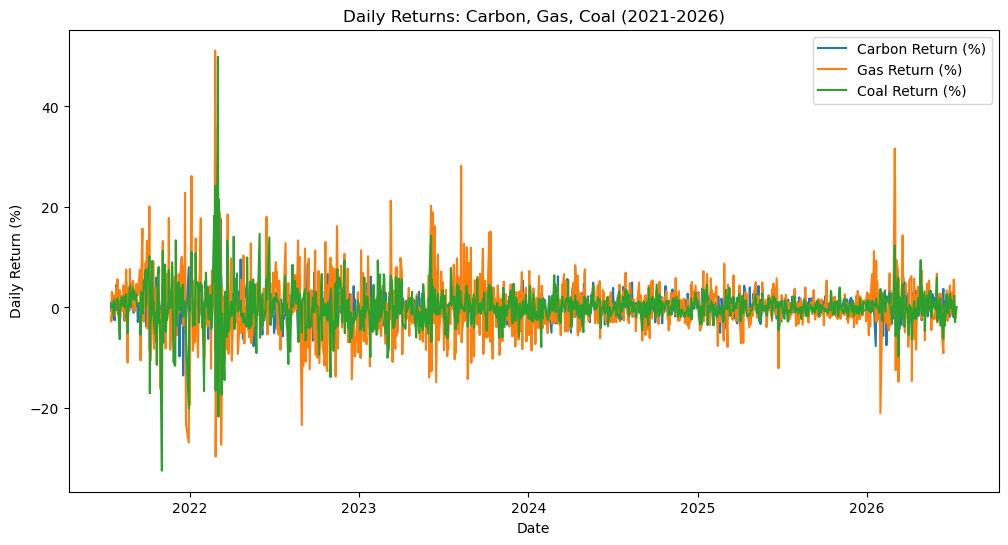

In [9]:
plt.figure(figsize=(12,6))
plt.plot(data["Date"], data["Carbon Return (%)"], label="Carbon Return (%)")
plt.plot(data["Date"], data["Gas Return (%)"], label="Gas Return (%)")
plt.plot(data["Date"], data["Coal Return (%)"], label="Coal Return (%)")
plt.legend()
plt.title("Daily Returns: Carbon, Gas, Coal (2021-2026)")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.show()

In [10]:
correlation = data[["Carbon Return (%)", "Gas Return (%)", "Coal Return (%)"]].corr()

correlation

,Carbon Return (%),Gas Return (%),Coal Return (%)
Carbon Return (%),1.000000,0.132302,0.046478
Gas Return (%),0.132302,1.000000,0.586722
Coal Return (%),0.046478,0.586722,1.000000


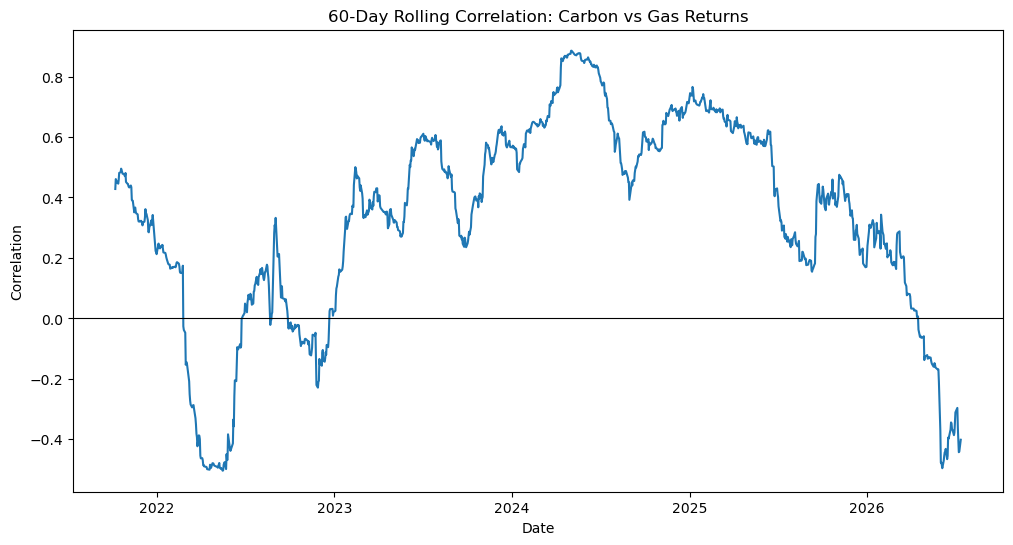

In [11]:
data["Rolling Corr (Carbon-Gas)"] = data["Carbon Return (%)"].rolling(60).corr(data["Gas Return (%)"])

plt.figure(figsize=(12,6))
plt.plot(data["Date"], data["Rolling Corr (Carbon-Gas)"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("60-Day Rolling Correlation: Carbon vs Gas Returns")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.show()

In [12]:
!pip install statsmodels

In [13]:
import statsmodels.api as sm

X = data[["Gas Return (%)", "Coal Return (%)"]]
X = sm.add_constant(X)
y = data["Carbon Return (%)"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Carbon Return (%)   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     11.85
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           7.98e-06
Time:                        13:10:22   Log-Likelihood:                -2847.8
No. Observations:                1228   AIC:                             5702.
Df Residuals:                    1225   BIC:                             5717.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0528      0.070     

In [14]:
X_hedge = sm.add_constant(data["Gas Return (%)"])
y_hedge = data["Carbon Return (%)"]

hedge_model = sm.OLS(y_hedge, X_hedge).fit()
print(hedge_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Carbon Return (%)   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     21.84
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           3.29e-06
Time:                        13:16:39   Log-Likelihood:                -2848.7
No. Observations:                1228   AIC:                             5701.
Df Residuals:                    1226   BIC:                             5712.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0531      0.070      0.

In [15]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.4/930.4 kB 4.5 MB/s  0:00:0036m-:--:--


In [16]:
from arch import arch_model

garch_model = arch_model(data["Carbon Return (%)"], vol="Garch", p=1, q=1)
garch_fit = garch_model.fit(disp="off")

print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:      Carbon Return (%)   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2737.44
Distribution:                  Normal   AIC:                           5482.87
Method:            Maximum Likelihood   BIC:                           5503.32
                                        No. Observations:                 1228
Date:                Mon, Jul 13 2026   Df Residuals:                     1227
Time:                        13:17:54   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0336  6.232e-02      0.540      0.590 [-8.85

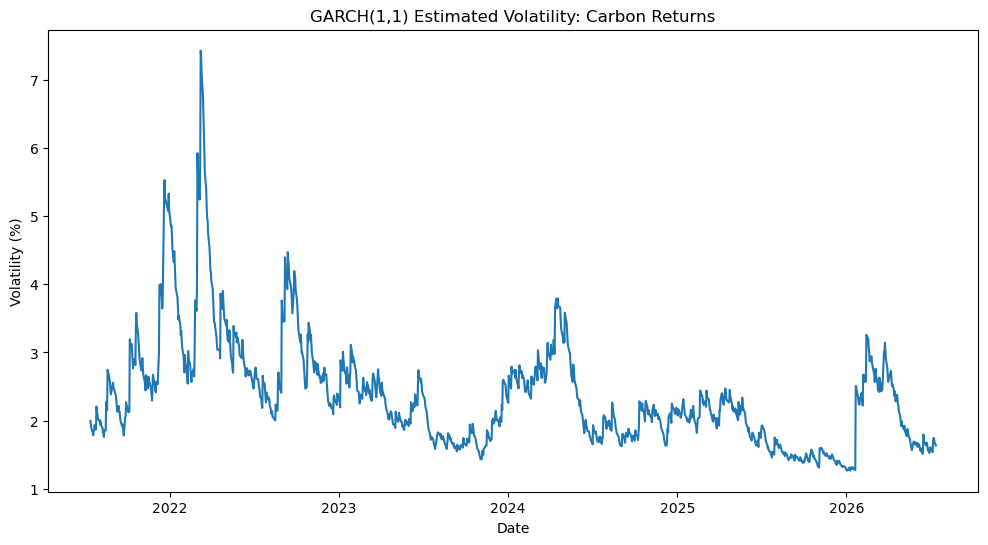

In [17]:
plt.figure(figsize=(12,6))
plt.plot(data["Date"], garch_fit.conditional_volatility)
plt.title("GARCH(1,1) Estimated Volatility: Carbon Returns")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.show()

In [18]:
data["Predicted Carbon Return (%)"] = hedge_model.predict(X_hedge)
data["Abnormal Return (%)"] = data["Carbon Return (%)"] - data["Predicted Carbon Return (%)"]

data.head()

,Date,Carbon,Gas,Coal,Carbon Return (%),Gas Return (%),Coal Return (%),Rolling Corr (Carbon-Gas),Predicted Carbon Return (%),Abnormal Return (%)
0,2021-07-14,53.30,34.775,129.70,0.966092,-1.940050,0.177647,NaN,-0.054435,1.020527
1,2021-07-15,52.91,33.797,129.63,-0.731707,-2.812365,-0.053971,NaN,-0.102765,-0.628942
2,2021-07-16,52.82,34.842,130.48,-0.170100,3.091990,0.655712,NaN,0.224363,-0.394463
3,2021-07-19,52.34,35.649,131.60,-0.908747,2.316170,0.858369,NaN,0.181379,-1.090126
4,2021-07-20,51.15,35.165,129.52,-2.273596,-1.357682,-1.580547,NaN,-0.022169,-2.251427


In [20]:
import pandas as pd

events = {
    "Fit for 55 Announcement": "2021-07-14",
    "Russia-Ukraine War Start": "2022-02-24",
    "Energy Crisis Peak": "2022-08-26",
    "CBAM Agreement": "2022-12-13",
    "EU ETS Reform Adopted": "2023-04-25",
    "EU 2040 Climate Target": "2024-02-06",
    "Middle East War Start": "2026-02-28",
    "Middle East War Ceasefire": "2026-04-08"
}

for name, date in events.items():
    event_date = pd.to_datetime(date)
    window = data[(data["Date"] >= event_date - pd.Timedelta(days=5)) &
                  (data["Date"] <= event_date + pd.Timedelta(days=5))]
    avg_abnormal = window["Abnormal Return (%)"].mean()
    print(f"{name} ({date}): average abnormal return in +/-5 day window = {avg_abnormal:.3f}%")

Fit for 55 Announcement (2021-07-14): average abnormal return in +/-5 day window = -0.273%
Russia-Ukraine War Start (2022-02-24): average abnormal return in +/-5 day window = -4.674%
Energy Crisis Peak (2022-08-26): average abnormal return in +/-5 day window = -2.849%
CBAM Agreement (2022-12-13): average abnormal return in +/-5 day window = -0.553%
EU ETS Reform Adopted (2023-04-25): average abnormal return in +/-5 day window = -1.028%
EU 2040 Climate Target (2024-02-06): average abnormal return in +/-5 day window = -1.206%
Middle East War Start (2026-02-28): average abnormal return in +/-5 day window = -0.868%
Middle East War Ceasefire (2026-04-08): average abnormal return in +/-5 day window = 0.280%


In [21]:
from scipy import stats

for name, date in events.items():
    event_date = pd.to_datetime(date)
    window = data[(data["Date"] >= event_date - pd.Timedelta(days=5)) &
                  (data["Date"] <= event_date + pd.Timedelta(days=5))]
    abnormal_returns = window["Abnormal Return (%)"].dropna()
    
    avg_abnormal = abnormal_returns.mean()
    t_stat, p_value = stats.ttest_1samp(abnormal_returns, 0)
    
    significance = "significant" if p_value < 0.05 else "not significant"
    print(f"{name} ({date}): avg abnormal return = {avg_abnormal:.3f}%, t-stat = {t_stat:.3f}, p-value = {p_value:.3f} ({significance})")

Fit for 55 Announcement (2021-07-14): avg abnormal return = -0.273%, t-stat = -0.601, p-value = 0.590 (not significant)
Russia-Ukraine War Start (2022-02-24): avg abnormal return = -4.674%, t-stat = -1.292, p-value = 0.253 (not significant)
Energy Crisis Peak (2022-08-26): avg abnormal return = -2.849%, t-stat = -1.998, p-value = 0.093 (not significant)
CBAM Agreement (2022-12-13): avg abnormal return = -0.553%, t-stat = -0.834, p-value = 0.436 (not significant)
EU ETS Reform Adopted (2023-04-25): avg abnormal return = -1.028%, t-stat = -1.744, p-value = 0.132 (not significant)
EU 2040 Climate Target (2024-02-06): avg abnormal return = -1.206%, t-stat = -1.574, p-value = 0.167 (not significant)
Middle East War Start (2026-02-28): avg abnormal return = -0.868%, t-stat = -1.203, p-value = 0.263 (not significant)
Middle East War Ceasefire (2026-04-08): avg abnormal return = 0.280%, t-stat = 0.403, p-value = 0.707 (not significant)


In [22]:
for name, date in events.items():
    event_date = pd.to_datetime(date)
    window = data[(data["Date"] >= event_date - pd.Timedelta(days=10)) &
                  (data["Date"] <= event_date + pd.Timedelta(days=10))]
    abnormal_returns = window["Abnormal Return (%)"].dropna()
    
    avg_abnormal = abnormal_returns.mean()
    t_stat, p_value = stats.ttest_1samp(abnormal_returns, 0)
    
    significance = "significant" if p_value < 0.05 else "not significant"
    print(f"{name} ({date}): avg abnormal return = {avg_abnormal:.3f}%, t-stat = {t_stat:.3f}, p-value = {p_value:.3f} ({significance})")

Fit for 55 Announcement (2021-07-14): avg abnormal return = -0.515%, t-stat = -0.978, p-value = 0.361 (not significant)
Russia-Ukraine War Start (2022-02-24): avg abnormal return = -2.884%, t-stat = -1.790, p-value = 0.097 (not significant)
Energy Crisis Peak (2022-08-26): avg abnormal return = -1.162%, t-stat = -1.164, p-value = 0.267 (not significant)
CBAM Agreement (2022-12-13): avg abnormal return = 0.068%, t-stat = 0.140, p-value = 0.890 (not significant)
EU ETS Reform Adopted (2023-04-25): avg abnormal return = -0.655%, t-stat = -1.428, p-value = 0.177 (not significant)
EU 2040 Climate Target (2024-02-06): avg abnormal return = -0.700%, t-stat = -1.307, p-value = 0.212 (not significant)
Middle East War Start (2026-02-28): avg abnormal return = 0.015%, t-stat = 0.026, p-value = 0.980 (not significant)
Middle East War Ceasefire (2026-04-08): avg abnormal return = 0.699%, t-stat = 1.120, p-value = 0.284 (not significant)


In [23]:
def structural_break_test(event_name, event_date_str, days_window=90):
    event_date = pd.to_datetime(event_date_str)
    
    before = data[(data["Date"] < event_date) & 
                  (data["Date"] >= event_date - pd.Timedelta(days=days_window))]["Carbon Return (%)"]
    after = data[(data["Date"] > event_date) & 
                 (data["Date"] <= event_date + pd.Timedelta(days=days_window))]["Carbon Return (%)"]
    
    mean_before, mean_after = before.mean(), after.mean()
    std_before, std_after = before.std(), after.std()
    
    t_stat, p_value_mean = stats.ttest_ind(before, after, equal_var=False)
    f_stat, p_value_var = stats.levene(before, after)
    
    print(f"--- {event_name} ({event_date_str}) ---")
    print(f"Mean return: before = {mean_before:.3f}%, after = {mean_after:.3f}% | t-test p-value = {p_value_mean:.3f}")
    print(f"Volatility (std): before = {std_before:.3f}%, after = {std_after:.3f}% | Levene's test p-value = {p_value_var:.3f}")
    print()

structural_break_test("Russia-Ukraine War Start", "2022-02-24")
structural_break_test("Middle East War Start", "2026-02-28")

--- Russia-Ukraine War Start (2022-02-24) ---
Mean return: before = 0.527%, after = -0.006% | t-test p-value = 0.494
Volatility (std): before = 3.880%, after = 4.584% | Levene's test p-value = 0.666

--- Middle East War Start (2026-02-28) ---
Mean return: before = -0.288%, after = 0.276% | t-test p-value = 0.146
Volatility (std): before = 2.173%, after = 2.063% | Levene's test p-value = 0.909



In [25]:
import numpy as np

position_size = 10_000_000  # €10 million hypothetical carbon exposure

var_95 = np.percentile(data["Carbon Return (%)"], 5)
var_99 = np.percentile(data["Carbon Return (%)"], 1)

var_95_euro = position_size * (var_95 / 100)
var_99_euro = position_size * (var_99 / 100)

print(f"1-Day 95% VaR: {var_95:.3f}% daily return -> €{var_95_euro:,.0f}")
print(f"1-Day 99% VaR: {var_99:.3f}% daily return -> €{var_99_euro:,.0f}")

1-Day 95% VaR: -3.592% daily return -> €-359,248
1-Day 99% VaR: -6.821% daily return -> €-682,055


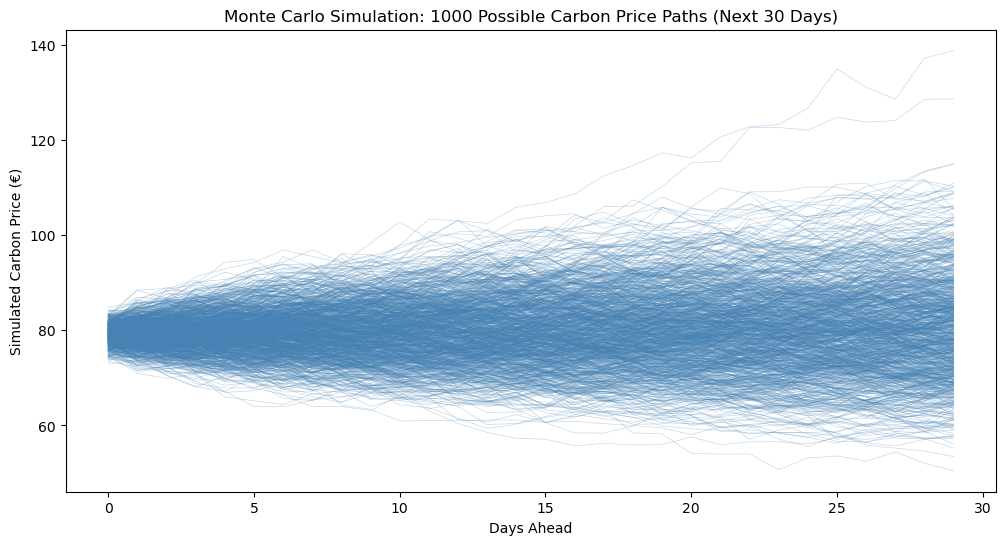

In [26]:
np.random.seed(42)

n_simulations = 1000
n_days = 30

mean_return = data["Carbon Return (%)"].mean() / 100
std_return = data["Carbon Return (%)"].std() / 100

last_price = data["Carbon"].iloc[-1]

simulated_paths = np.zeros((n_days, n_simulations))

for sim in range(n_simulations):
    price = last_price
    for day in range(n_days):
        daily_return = np.random.normal(mean_return, std_return)
        price = price * (1 + daily_return)
        simulated_paths[day, sim] = price

plt.figure(figsize=(12,6))
plt.plot(simulated_paths, linewidth=0.5, alpha=0.3, color="steelblue")
plt.title(f"Monte Carlo Simulation: {n_simulations} Possible Carbon Price Paths (Next {n_days} Days)")
plt.xlabel("Days Ahead")
plt.ylabel("Simulated Carbon Price (€)")
plt.show()